In [1]:
# ====================================================
# Project 4: Portfolio Optimization & Risk Management
# 4 Companies 
# AstraZeneca--AZN.L---Pharmaceuticals
# GSK--GSK>L--Pharmaceuticals
# Shell--SHEL.L--Energy
# Auto Trader Group--AUTO>L--Technology/Consumer Platform
# ====================================================
# Step 1: Enviromment Setup

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Display configuration
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Environment ready.")
print(f"Run timestamp: {datetime.now()}")


Environment ready.
Run timestamp: 2026-06-22 14:37:31.896313


In [2]:
#=============================================================
# Step 1- Define Inputs: The Capital Base & Asset Universerve
#=============================================================

TOTAL_CAPITAL = 100_000          # Simulated capital base (USD-equivalent, GBP positions)
MAX_RISK_PER_TRADE = 0.01        # 1% maximum risk per single position (the brief's "1% Rule")
MAX_PORTFOLIO_HEAT = 0.08        # 8% maximum simultaneous loss (gatekeeper constraint)
MAX_PORTFOLIO_BETA = 1.0         # Portfolio must be defensive relative to the market

TICKERS = ['AZN.L', 'GSK.L', 'SHEL.L', 'AUTO.L']
SECTOR_MAP = {
    'AZN.L': 'Pharmaceuticals',
    'GSK.L': 'Pharmaceuticals',
    'SHEL.L': 'Energy',
    'AUTO.L': 'Technology/Consumer'
}
BENCHMARK = '^FTSE'

YEARS_OF_HISTORY = 6
END_DATE = datetime.now()
START_DATE = END_DATE.replace(year=END_DATE.year - YEARS_OF_HISTORY)

print(f"Capital Base:           ${TOTAL_CAPITAL:,}")
print(f"Max Risk per Trade:     {MAX_RISK_PER_TRADE:.0%}  (${TOTAL_CAPITAL * MAX_RISK_PER_TRADE:,.0f})")
print(f"Max Portfolio Heat:     {MAX_PORTFOLIO_HEAT:.0%}")
print(f"Max Portfolio Beta:     {MAX_PORTFOLIO_BETA}")
print(f"Data window:            {START_DATE.date()} to {END_DATE.date()}")
print(f"Assets:                 {TICKERS}")
print(f"Benchmark:               {BENCHMARK}")


Capital Base:           $100,000
Max Risk per Trade:     1%  ($1,000)
Max Portfolio Heat:     8%
Max Portfolio Beta:     1.0
Data window:            2020-06-22 to 2026-06-22
Assets:                 ['AZN.L', 'GSK.L', 'SHEL.L', 'AUTO.L']
Benchmark:               ^FTSE


In [3]:
# Download weekly adjusted close prices for all assets + benchmark
all_symbols = TICKERS + [BENCHMARK]

raw_data = yf.download(
    all_symbols,
    start=START_DATE,
    end=END_DATE,
    interval='1wk',
    auto_adjust=True,
    progress=False
)

prices = raw_data['Close'].dropna(how='all')
prices = prices[all_symbols]  # enforce consistent column order

print(f"Data shape: {prices.shape}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
prices.tail()


Data shape: (313, 5)
Date range: 2020-06-22 to 2026-06-15


Ticker,AZN.L,GSK.L,SHEL.L,AUTO.L,^FTSE
Date,,,,,
2026-05-18,"13,916.0000","1,915.0000","3,204.7124",454.4000,"10,466.2998"
2026-05-25,"13,802.0000","1,881.5000","3,118.0000",441.5000,"10,409.2998"
2026-06-01,"13,858.0000","1,938.0000","3,227.5000",468.7000,"10,368.0996"
2026-06-08,"13,462.0000","1,984.0000","3,220.5000",463.7000,"10,471.7002"
2026-06-15,"13,234.0000","1,925.5000","2,993.5000",478.0000,"10,363.2998"


In [4]:
# Sanity check: confirm no asset has excessive missing data
missing_pct = prices.isna().mean() * 100
print("Missing data % per symbol:")
print(missing_pct)

# Forward-fill small gaps (holidays/non-trading days), then drop any remaining NaN rows
prices = prices.ffill().dropna()
print(f"\nFinal clean shape: {prices.shape}")


Missing data % per symbol:
Ticker
AZN.L    0.0000
GSK.L    0.0000
SHEL.L   0.0000
AUTO.L   0.0000
^FTSE    0.0000
dtype: float64

Final clean shape: (313, 5)


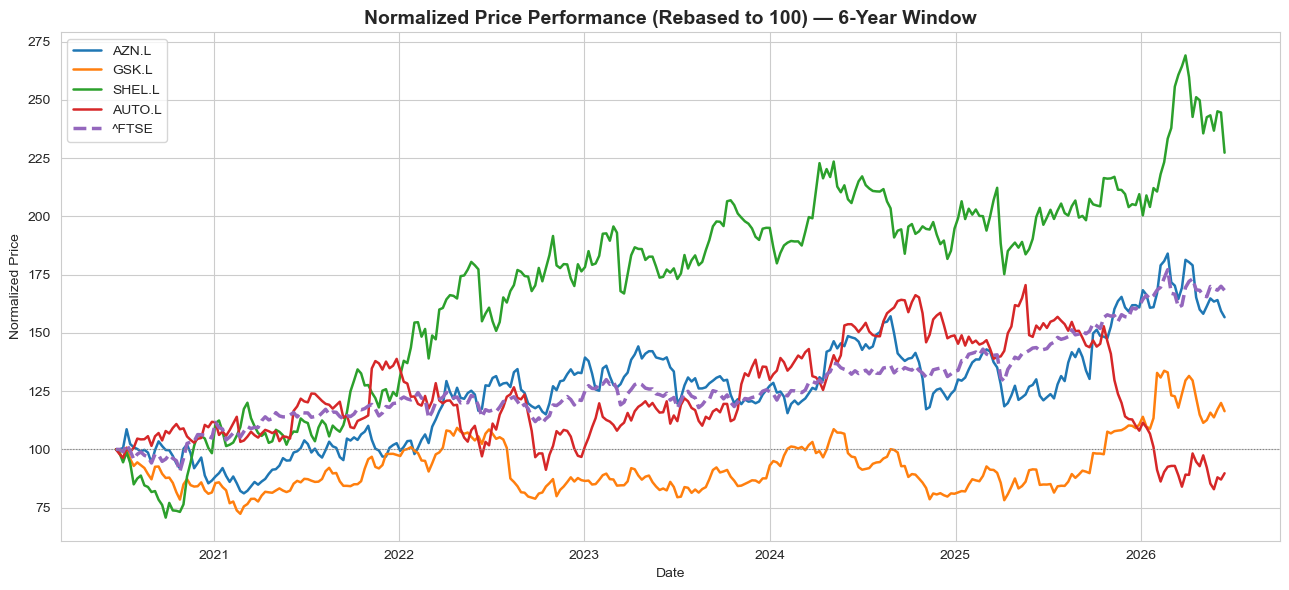

In [5]:
# ---------Chart 1----------
# Visualize normalized price performance (rebased to 100 at start) for context
normalized = (prices / prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(13, 6))
for col in normalized.columns:
    style = '--' if col == BENCHMARK else '-'
    lw = 2.5 if col == BENCHMARK else 1.8
    ax.plot(normalized.index, normalized[col], style, label=col, linewidth=lw)

ax.set_title('Normalized Price Performance (Rebased to 100) — 6-Year Window', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Price')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.axhline(100, color='grey', linewidth=0.8, linestyle=':')
plt.tight_layout()
plt.savefig('p4_normalized_prices.png', dpi=150)
plt.show()


In [6]:
#=====================================================
# Step 2A-Calculate Returns & the Correlation
#=====================================================
# Weekly log returns (more statistically well-behaved than simple returns for covariance/beta math)
returns = np.log(prices / prices.shift(1)).dropna()

print(f"Returns shape: {returns.shape}")
returns.describe()


Returns shape: (312, 5)


Ticker,AZN.L,GSK.L,SHEL.L,AUTO.L,^FTSE
count,312.0000,312.0000,312.0000,312.0000,312.0000
mean,0.0014,0.0005,0.0026,-0.0003,0.0017
std,0.0321,0.0310,0.0360,0.0361,0.0182
min,-0.1092,-0.1395,-0.1391,-0.1346,-0.0723
25%,-0.0154,-0.0159,-0.0167,-0.0194,-0.0073
50%,0.0040,0.0004,0.0012,0.0000,0.0024
75%,0.0199,0.0170,0.0234,0.0211,0.0127
max,0.1398,0.1581,0.1454,0.1620,0.0665


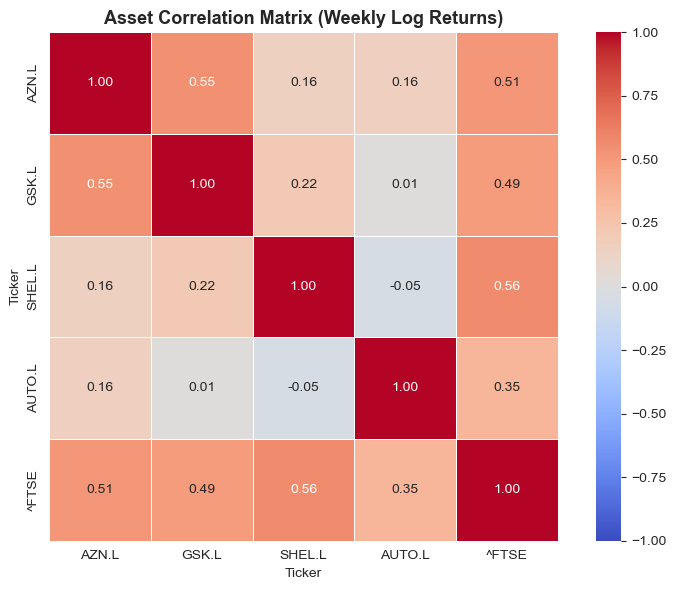


Correlation Matrix:
Ticker  AZN.L  GSK.L  SHEL.L  AUTO.L  ^FTSE
Ticker                                     
AZN.L  1.0000 0.5460  0.1560  0.1560 0.5100
GSK.L  0.5460 1.0000  0.2180  0.0150 0.4890
SHEL.L 0.1560 0.2180  1.0000 -0.0530 0.5630
AUTO.L 0.1560 0.0150 -0.0530  1.0000 0.3460
^FTSE  0.5100 0.4890  0.5630  0.3460 1.0000


In [7]:
# ---------------Chart 2---------
# Correlation matrix across all assets + benchmark
corr_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Asset Correlation Matrix (Weekly Log Returns)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p4_correlation_matrix.png', dpi=150)
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix.round(3))


In [8]:
# Isolate the asset-to-asset correlations (excluding benchmark) to verify the diversification thesis
asset_corr = corr_matrix.loc[TICKERS, TICKERS]
avg_pairwise_corr = (asset_corr.values.sum() - len(TICKERS)) / (len(TICKERS) ** 2 - len(TICKERS))

print("Asset-to-Asset Correlation (excluding benchmark):")
print(asset_corr.round(3))
print(f"\nAverage pairwise correlation: {avg_pairwise_corr:.3f}")

if avg_pairwise_corr < 0.5:
    print("VERDICT: Assets are minimally correlated. Diversification thesis CONFIRMED.")
else:
    print("VERDICT: Assets show meaningful co-movement. Diversification benefit is limited.")


Asset-to-Asset Correlation (excluding benchmark):
Ticker  AZN.L  GSK.L  SHEL.L  AUTO.L
Ticker                              
AZN.L  1.0000 0.5460  0.1560  0.1560
GSK.L  0.5460 1.0000  0.2180  0.0150
SHEL.L 0.1560 0.2180  1.0000 -0.0530
AUTO.L 0.1560 0.0150 -0.0530  1.0000

Average pairwise correlation: 0.173
VERDICT: Assets are minimally correlated. Diversification thesis CONFIRMED.


In [9]:
# ===============================================
# Step 2B: The Covariance Matrix (MPT Foundation)
# ===============================================

# Annualized covariance matrix (asset returns only, excluding benchmark)
asset_returns = returns[TICKERS]
cov_matrix_annual = asset_returns.cov() * 52

print("Annualized Covariance Matrix:")
print(cov_matrix_annual.round(5))

# Annualized volatility (standard deviation) per asset, for reference
annual_vol = asset_returns.std() * np.sqrt(52)
print("\nAnnualized Volatility per Asset:")
print(annual_vol.round(4))


Annualized Covariance Matrix:
Ticker  AZN.L  GSK.L  SHEL.L  AUTO.L
Ticker                              
AZN.L  0.0536 0.0282  0.0094  0.0094
GSK.L  0.0282 0.0498  0.0126  0.0008
SHEL.L 0.0094 0.0126  0.0676 -0.0036
AUTO.L 0.0094 0.0008 -0.0036  0.0678

Annualized Volatility per Asset:
Ticker
AZN.L    0.2315
GSK.L    0.2232
SHEL.L   0.2599
AUTO.L   0.2603
dtype: float64


In [10]:
# ==================================================
# Step 3: Calculate Systemic Risk (Beta) vs FTSE 100
# ==================================================

market_returns = returns[BENCHMARK]
market_var = np.var(market_returns)

betas = {}
for ticker in TICKERS:
    asset_ret = returns[ticker]
    covariance = np.cov(asset_ret, market_returns)[0, 1]
    beta = covariance / market_var
    betas[ticker] = beta

beta_series = pd.Series(betas, name='Beta vs FTSE 100')
print("Individual Asset Betas (vs FTSE 100):")
print(beta_series.round(3))

for t in TICKERS:
    profile = "AGGRESSIVE (amplifies market)" if betas[t] > 1.0 else "DEFENSIVE (dampens market)"
    print(f"  {t:8s} (β={betas[t]:.3f}) — {profile}")

Individual Asset Betas (vs FTSE 100):
AZN.L    0.9010
GSK.L    0.8340
SHEL.L   1.1180
AUTO.L   0.6870
Name: Beta vs FTSE 100, dtype: float64
  AZN.L    (β=0.901) — DEFENSIVE (dampens market)
  GSK.L    (β=0.834) — DEFENSIVE (dampens market)
  SHEL.L   (β=1.118) — AGGRESSIVE (amplifies market)
  AUTO.L   (β=0.687) — DEFENSIVE (dampens market)


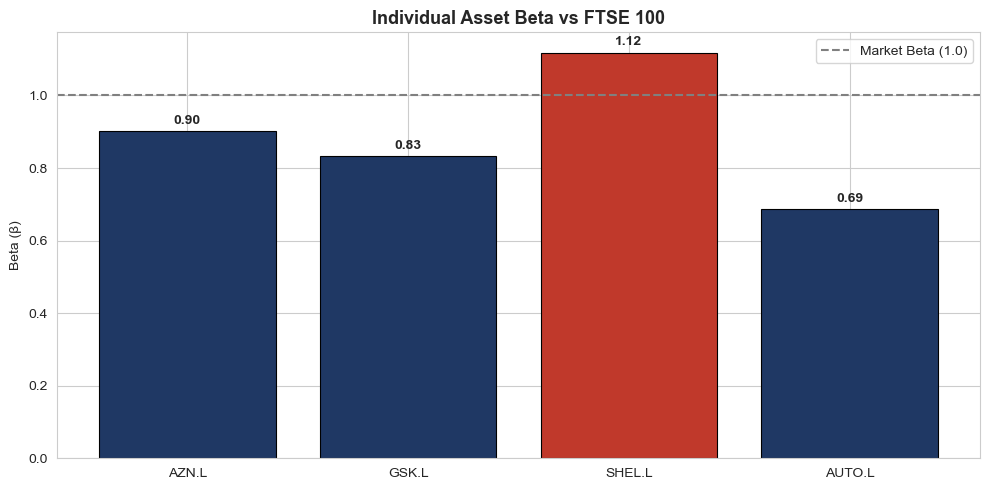

In [11]:
# Visualize beta profile vs the market gear (β=1.0 reference line)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1F3864' if b < 1.0 else '#C0392B' for b in beta_series.values]
bars = ax.bar(beta_series.index, beta_series.values, color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(1.0, color='grey', linestyle='--', linewidth=1.5, label='Market Beta (1.0)')
ax.set_title('Individual Asset Beta vs FTSE 100', fontsize=13, fontweight='bold')
ax.set_ylabel('Beta (β)')
ax.legend()
for bar, val in zip(bars, beta_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
            ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('p4_individual_betas.png', dpi=150)
plt.show()

In [12]:
# ==============================================================
# Step 4: Derive Portfolio Weights (Beta-Constrained Allocation)
# ==============================================================

def inverse_beta_weights(betas_dict, min_w=0.10, max_w=0.35):
   
    BETA_FLOOR = 0.05
    safe_betas = {t: (b if b > 0 else BETA_FLOOR) for t, b in betas_dict.items()}

    inv_beta = {t: 1.0 / b for t, b in safe_betas.items()}
    total_inv = sum(inv_beta.values())
    raw_weights = {t: v / total_inv for t, v in inv_beta.items()}

    # Clip to bounds
    clipped = {t: float(np.clip(w, min_w, max_w)) for t, w in raw_weights.items()}

    # Re-normalize after clipping so weights sum to 1.0 again
    total_clipped = sum(clipped.values())
    final_weights = {t: w / total_clipped for t, w in clipped.items()}
    return final_weights

weights_dict = inverse_beta_weights(betas)
weights_series = pd.Series(weights_dict, name='Weight')[TICKERS]

print("Derived Portfolio Weights (Inverse-Beta, Bounded 10%-35%):")
print(weights_series.round(4))
print(f"\nSum check: {weights_series.sum():.4f}  (must equal 1.0000)")

Derived Portfolio Weights (Inverse-Beta, Bounded 10%-35%):
AZN.L    0.2382
GSK.L    0.2575
SHEL.L   0.1920
AUTO.L   0.3123
Name: Weight, dtype: float64

Sum check: 1.0000  (must equal 1.0000)


In [13]:
# Calculate resulting portfolio beta with these weights
portfolio_beta = sum(weights_series[t] * betas[t] for t in TICKERS)
print(f"Resulting Portfolio Beta (β_p) = {portfolio_beta:.4f}")

if portfolio_beta < MAX_PORTFOLIO_BETA:
    margin = (MAX_PORTFOLIO_BETA - portfolio_beta)
    print(f"GATEKEEPER 1 STATUS: PASS — β_p = {portfolio_beta:.3f} is below the 1.0 ceiling "
          f"(margin: {margin:.3f}).")
else:
    print(f"GATEKEEPER 1 STATUS: FAIL — β_p = {portfolio_beta:.3f} exceeds the 1.0 ceiling. "
          f"Weights must be adjusted further toward defensive assets.")

Resulting Portfolio Beta (β_p) = 0.8587
GATEKEEPER 1 STATUS: PASS — β_p = 0.859 is below the 1.0 ceiling (margin: 0.141).


In [14]:
# Dollar allocation per asset
allocation_dollars = (weights_series * TOTAL_CAPITAL).round(2)

allocation_table = pd.DataFrame({
    'Sector': [SECTOR_MAP[t] for t in TICKERS],
    'Beta': [round(betas[t], 3) for t in TICKERS],
    'Weight': weights_series.values,
    'Allocated ($)': allocation_dollars.values
})
allocation_table.index = TICKERS
print(allocation_table)
print(f"\nTotal Allocated: ${allocation_table['Allocated ($)'].sum():,.2f}  (must equal $100,000.00)")

                     Sector   Beta  Weight  Allocated ($)
AZN.L       Pharmaceuticals 0.9010  0.2382    23,818.4400
GSK.L       Pharmaceuticals 0.8340  0.2575    25,753.2300
SHEL.L               Energy 1.1180  0.1920    19,198.5600
AUTO.L  Technology/Consumer 0.6870  0.3123    31,229.7700

Total Allocated: $100,000.00  (must equal $100,000.00)


In [15]:
# ============================================================
# Step 5 — Structural Stop-Losses & The Position Sizing Funnel
# ============================================================
# Get the most recent closing price for each asset as the assumed entry price
entry_prices = prices[TICKERS].iloc[-1]
print("Entry Prices (most recent close):")
print(entry_prices.round(2))


Entry Prices (most recent close):
Ticker
AZN.L    13,234.0000
GSK.L     1,925.5000
SHEL.L    2,993.5000
AUTO.L      478.0000
Name: 2026-06-15 00:00:00, dtype: float64


In [16]:
# Derive stop-loss % from each asset's weekly volatility
weekly_vol = asset_returns.std()  # weekly log-return std dev per asset

def derive_stop_loss_pct(vol, multiplier=2.0, min_stop=0.05, max_stop=0.12):
    raw_stop = vol * multiplier
    return float(np.clip(raw_stop, min_stop, max_stop))

stop_loss_pct = {t: derive_stop_loss_pct(weekly_vol[t]) for t in TICKERS}
stop_loss_series = pd.Series(stop_loss_pct, name='Stop-Loss %')[TICKERS]

print("Derived Stop-Loss Percentages:")
print(stop_loss_series.round(4))


Derived Stop-Loss Percentages:
AZN.L    0.0642
GSK.L    0.0619
SHEL.L   0.0721
AUTO.L   0.0722
Name: Stop-Loss %, dtype: float64


In [17]:
# Build the full position sizing table
position_table = allocation_table.copy()
position_table['Entry Price'] = entry_prices.values
position_table['Stop-Loss %'] = stop_loss_series.values
position_table['Stop-Loss Price'] = (position_table['Entry Price'] *
                                       (1 - position_table['Stop-Loss %'])).round(2)

# --- The Position Sizing Funnel ---
# 1. Absolute Dollar Risk = total capital x risk percentage for that position
#    We use MAX_RISK_PER_TRADE (1%) as the hard ceiling per the brief's "1% Rule"
position_table['Max Dollar Risk (1%% Rule)'] = TOTAL_CAPITAL * MAX_RISK_PER_TRADE

# 2. Distance to stop-loss (per share)
position_table['Stop Distance ($/share)'] = (position_table['Entry Price'] -
                                                position_table['Stop-Loss Price']).round(4)

# 3. Exact position size (units) = Dollar Risk / Stop Distance per share
position_table['Position Size (units)'] = np.floor(
    position_table['Max Dollar Risk (1%% Rule)'] / position_table['Stop Distance ($/share)']
).astype(int)

# 4. Actual capital deployed if we bought that many units at entry price
position_table['Capital Deployed ($)'] = (position_table['Position Size (units)'] *
                                            position_table['Entry Price']).round(2)

# 5. Actual dollar risk if stop triggers (should be <= the 2% ceiling)
position_table['Actual $ Risk if Stopped'] = (position_table['Position Size (units)'] *
                                                position_table['Stop Distance ($/share)']).round(2)

print(position_table[['Sector', 'Beta', 'Weight', 'Allocated ($)', 'Entry Price',
                       'Stop-Loss %', 'Stop-Loss Price', 'Position Size (units)',
                       'Capital Deployed ($)', 'Actual $ Risk if Stopped']])

                     Sector   Beta  Weight  Allocated ($)  Entry Price  \
AZN.L       Pharmaceuticals 0.9010  0.2382    23,818.4400  13,234.0000   
GSK.L       Pharmaceuticals 0.8340  0.2575    25,753.2300   1,925.5000   
SHEL.L               Energy 1.1180  0.1920    19,198.5600   2,993.5000   
AUTO.L  Technology/Consumer 0.6870  0.3123    31,229.7700     478.0000   

        Stop-Loss %  Stop-Loss Price  Position Size (units)  \
AZN.L        0.0642      12,384.2300                      1   
GSK.L        0.0619       1,806.2900                      8   
SHEL.L       0.0721       2,777.7000                      4   
AUTO.L       0.0722         443.4900                     28   

        Capital Deployed ($)  Actual $ Risk if Stopped  
AZN.L            13,234.0000                  849.7700  
GSK.L            15,404.0000                  953.6800  
SHEL.L           11,974.0000                  863.2000  
AUTO.L           13,384.0000                  966.2800  


In [18]:
# =============================================================
# Step 6 — Verify the Gatekeeper Constraints
# =============================================================
# Portfolio Heat: allocation-weighted stop-loss risk, summed across all positions
position_table['Heat Contribution ($)'] = (position_table['Allocated ($)'] *
                                             position_table['Stop-Loss %']).round(2)

total_heat_dollars = position_table['Heat Contribution ($)'].sum()
total_heat_pct = total_heat_dollars / TOTAL_CAPITAL

print("Heat Contribution by Asset:")
print(position_table[['Sector', 'Allocated ($)', 'Stop-Loss %', 'Heat Contribution ($)']])

print(f"\nTotal Portfolio Heat: ${total_heat_dollars:,.2f}  ({total_heat_pct:.2%} of capital)")


Heat Contribution by Asset:
                     Sector  Allocated ($)  Stop-Loss %  Heat Contribution ($)
AZN.L       Pharmaceuticals    23,818.4400       0.0642             1,529.4200
GSK.L       Pharmaceuticals    25,753.2300       0.0619             1,594.4600
SHEL.L               Energy    19,198.5600       0.0721             1,384.0500
AUTO.L  Technology/Consumer    31,229.7700       0.0722             2,254.4800

Total Portfolio Heat: $6,762.41  (6.76% of capital)


In [19]:
# ============================================================
# FINAL GATEKEEPER VERDICT
# ============================================================
print("=" * 60)
print("GATEKEEPER CONSTRAINT VERIFICATION")
print("=" * 60)

# Constraint 1: Portfolio Beta
beta_pass = portfolio_beta < MAX_PORTFOLIO_BETA
print(f"\nConstraint 1 — Defensive Systemic Risk:")
print(f"  Portfolio Beta (β_p) = {portfolio_beta:.4f}")
print(f"  Requirement: β_p < {MAX_PORTFOLIO_BETA}")
print(f"  VERDICT: {'PASSED' if beta_pass else 'FAILED'}")
if beta_pass:
    market_shock = -10  # illustrative 10% market drop
    implied_move = market_shock * portfolio_beta
    print(f"  Interpretation: if the market drops {abs(market_shock)}%, this portfolio is "
          f"structurally designed to move only ~{abs(implied_move):.1f}%.")

# Constraint 2: Portfolio Heat
heat_pass = total_heat_pct <= MAX_PORTFOLIO_HEAT
print(f"\nConstraint 2 — Maximum Portfolio Heat:")
print(f"  Total Portfolio Heat = ${total_heat_dollars:,.2f} ({total_heat_pct:.2%})")
print(f"  Requirement: Heat <= {MAX_PORTFOLIO_HEAT:.0%}")
print(f"  VERDICT: {'PASSED' if heat_pass else 'FAILED'}")
if heat_pass:
    protected_pct = 1 - total_heat_pct
    print(f"  Interpretation: {protected_pct:.2%} of the capital base is structurally protected "
          f"against a total simultaneous market flash-crash.")

print(f"\n{'=' * 60}")
overall_pass = beta_pass and heat_pass
print(f"OVERALL PORTFOLIO STATUS: {'ALL GATEKEEPER CONSTRAINTS PASSED' if overall_pass else 'CONSTRAINTS FAILED — REBALANCE REQUIRED'}")
print("=" * 60)

GATEKEEPER CONSTRAINT VERIFICATION

Constraint 1 — Defensive Systemic Risk:
  Portfolio Beta (β_p) = 0.8587
  Requirement: β_p < 1.0
  VERDICT: PASSED
  Interpretation: if the market drops 10%, this portfolio is structurally designed to move only ~8.6%.

Constraint 2 — Maximum Portfolio Heat:
  Total Portfolio Heat = $6,762.41 (6.76%)
  Requirement: Heat <= 8%
  VERDICT: PASSED
  Interpretation: 93.24% of the capital base is structurally protected against a total simultaneous market flash-crash.

OVERALL PORTFOLIO STATUS: ALL GATEKEEPER CONSTRAINTS PASSED


In [20]:
# =======================================================
# Step 7 — Evaluating the Architecture: The Sharpe Ratio
#========================================================
# Risk-free rate: reuse the Project 2 convention (UK risk-free rate ~4.40%)
RISK_FREE_RATE = 0.0440

# Portfolio expected annual return: weighted average of each asset's annualized historical return
asset_annual_return = asset_returns.mean() * 52
portfolio_expected_return = sum(weights_series[t] * asset_annual_return[t] for t in TICKERS)

# Portfolio annualized volatility: sigma_p = sqrt(w^T * Sigma * w)
w_vector = weights_series[TICKERS].values
portfolio_variance = w_vector.T @ cov_matrix_annual.loc[TICKERS, TICKERS].values @ w_vector
portfolio_volatility = np.sqrt(portfolio_variance)

sharpe_ratio = (portfolio_expected_return - RISK_FREE_RATE) / portfolio_volatility

print(f"Portfolio Expected Annual Return:  {portfolio_expected_return:.2%}")
print(f"Portfolio Annualized Volatility:   {portfolio_volatility:.2%}")
print(f"Risk-Free Rate (UK proxy):         {RISK_FREE_RATE:.2%}")
print(f"\nSharpe Ratio = {sharpe_ratio:.3f}")

if sharpe_ratio > 1.0:
    quality = "Excellent risk-adjusted performance"
elif sharpe_ratio > 0.5:
    quality = "Acceptable/good risk-adjusted performance"
elif sharpe_ratio > 0:
    quality = "Sub-par risk-adjusted performance (return barely compensates for risk taken)"
else:
    quality = "Negative — the portfolio underperforms the risk-free rate on a risk-adjusted basis"
print(f"Interpretation: {quality}")


Portfolio Expected Annual Return:  4.50%
Portfolio Annualized Volatility:   14.87%
Risk-Free Rate (UK proxy):         4.40%

Sharpe Ratio = 0.007
Interpretation: Sub-par risk-adjusted performance (return barely compensates for risk taken)


In [21]:
# ==========================================================
# Step 8 — Submit the Schematic: Final Allocation Dashboard
#===========================================================
# Consolidated final dashboard table
final_dashboard = position_table[['Sector', 'Weight', 'Allocated ($)', 'Beta',
                                    'Stop-Loss %', 'Heat Contribution ($)']].copy()
final_dashboard.columns = ['Sector', 'Weight', 'Allocated ($)', 'Beta',
                            'Stop-Loss %', 'Absolute Risk ($)']

print("=" * 70)
print(" " * 20 + "FINAL PORTFOLIO DASHBOARD")
print("=" * 70)
print(final_dashboard)
print("-" * 70)
print(f"{'TOTAL CAPITAL DEPLOYED:':35s} ${final_dashboard['Allocated ($)'].sum():,.2f}")
print(f"{'WEIGHTED PORTFOLIO BETA:':35s} {portfolio_beta:.4f}  "
      f"({'PASS' if beta_pass else 'FAIL'} vs <1.0 ceiling)")
print(f"{'TOTAL PORTFOLIO HEAT:':35s} ${total_heat_dollars:,.2f} ({total_heat_pct:.2%})  "
      f"({'PASS' if heat_pass else 'FAIL'} vs <=8% ceiling)")
print(f"{'SHARPE RATIO:':35s} {sharpe_ratio:.3f}")
print("=" * 70)


                    FINAL PORTFOLIO DASHBOARD
                     Sector  Weight  Allocated ($)   Beta  Stop-Loss %  \
AZN.L       Pharmaceuticals  0.2382    23,818.4400 0.9010       0.0642   
GSK.L       Pharmaceuticals  0.2575    25,753.2300 0.8340       0.0619   
SHEL.L               Energy  0.1920    19,198.5600 1.1180       0.0721   
AUTO.L  Technology/Consumer  0.3123    31,229.7700 0.6870       0.0722   

        Absolute Risk ($)  
AZN.L          1,529.4200  
GSK.L          1,594.4600  
SHEL.L         1,384.0500  
AUTO.L         2,254.4800  
----------------------------------------------------------------------
TOTAL CAPITAL DEPLOYED:             $100,000.00
WEIGHTED PORTFOLIO BETA:            0.8587  (PASS vs <1.0 ceiling)
TOTAL PORTFOLIO HEAT:               $6,762.41 (6.76%)  (PASS vs <=8% ceiling)
SHARPE RATIO:                       0.007


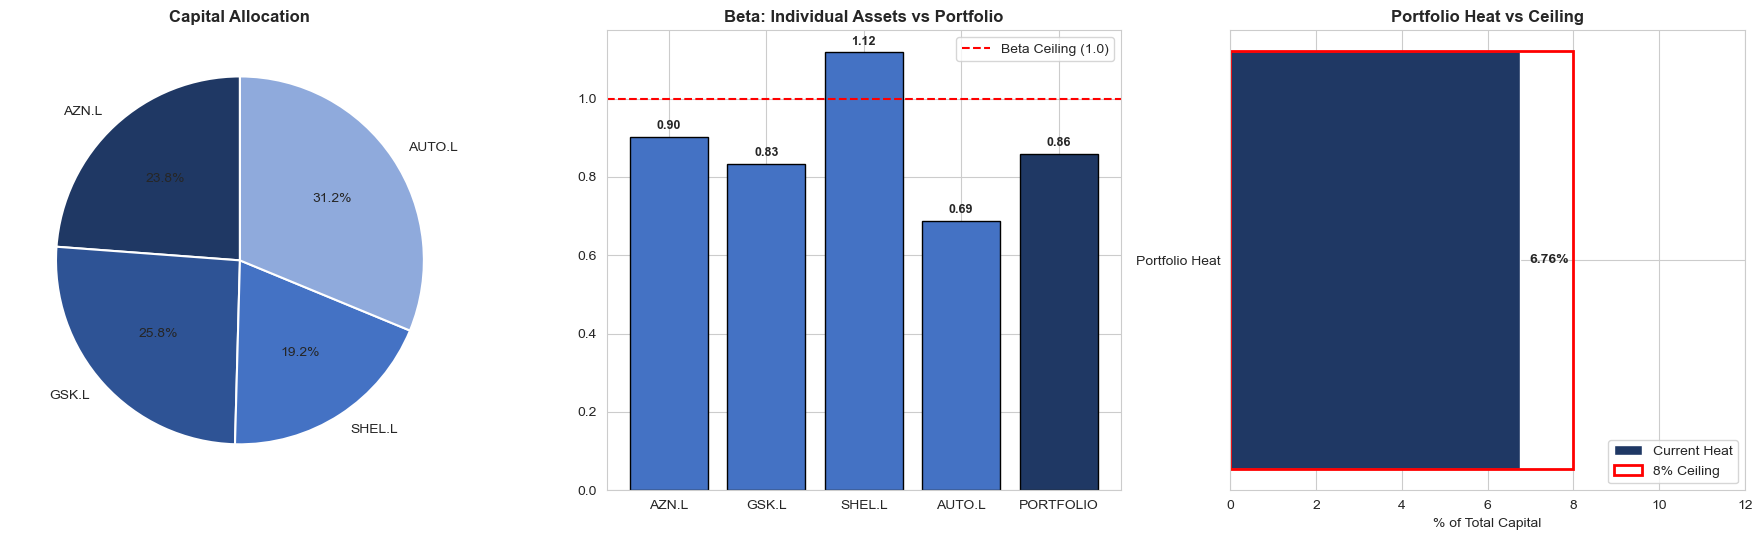

In [22]:
# Visual dashboard: allocation pie chart + beta comparison + heat gauge
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Panel 1: Allocation pie chart ---
colors_pie = ['#1F3864', '#2E5395', '#4472C4', '#8FAADC']
axes[0].pie(final_dashboard['Allocated ($)'], labels=final_dashboard.index,
            autopct='%1.1f%%', colors=colors_pie, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Capital Allocation', fontweight='bold')

# --- Panel 2: Beta comparison (individual vs portfolio) ---
beta_compare = list(beta_series.values) + [portfolio_beta]
labels_compare = list(beta_series.index) + ['PORTFOLIO']
colors_compare = ['#4472C4'] * len(beta_series) + ['#1F3864']
bars = axes[1].bar(labels_compare, beta_compare, color=colors_compare, edgecolor='black')
axes[1].axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Beta Ceiling (1.0)')
axes[1].set_title('Beta: Individual Assets vs Portfolio', fontweight='bold')
axes[1].legend()
for bar, val in zip(bars, beta_compare):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
                 ha='center', fontsize=9, fontweight='bold')

# --- Panel 3: Heat gauge (heat used vs ceiling) ---
axes[2].barh(['Portfolio Heat'], [total_heat_pct * 100], color='#1F3864', height=0.4,
             label='Current Heat')
axes[2].barh(['Portfolio Heat'], [MAX_PORTFOLIO_HEAT * 100], color='none',
             edgecolor='red', linewidth=2, height=0.4, label='8% Ceiling')
axes[2].set_xlim(0, 12)
axes[2].set_xlabel('% of Total Capital')
axes[2].set_title('Portfolio Heat vs Ceiling', fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].text(total_heat_pct * 100 + 0.2, 0, f'{total_heat_pct:.2%}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('p4_final_dashboard.png', dpi=150)
plt.show()